# Location Risk Radar
### An early warning system for restaurant chain location closure risk

**Team LRR Analytics.** CIS 509, W. P. Carey School of Business, Arizona State University

**Members:** Andy Lin | Hunain Akbar | Ishani Patel | Jake Ida | Yukti Gandhi

- Live app: https://location-risk-radar-lrr-cis509.streamlit.app
- GitHub repo: https://github.com/SyedHunainAkbar/location-risk-radar

## Executive summary

We flag restaurant chain locations at elevated risk of closure and explain why using
the language of customer reviews. The default operating metric, average star rating,
barely separates survivors from closures, so we build the signal from engagement
dynamics and review text instead.

Five headline numbers frame the work:

1. **0.026 stars.** The average rating gap between open and closed restaurants across
   all 52,268 Yelp restaurants (EDA). Stars alone barely distinguish them.
2. **2,054 locations, 30 chains.** The locked cohort (15 Fast Food, 15 Non-Fast Food)
   reproduced exactly from the EDA; 1,545 were active at the 2018 landmark and are
   scored, the other 509 had already gone quiet and are reported, not scored.
3. **+0.037 C index in Fast Food.** Engagement plus review text lifts the Fast Food
   survival model from 0.640 (stars only) to 0.677 under chain-grouped cross
   validation, where 59 of the 65 closures occur.
4. **9 complaint themes beat 68 raw topics.** Collapsing BERTopic topics into
   operational themes raises the pooled full-model C index from 0.593 to 0.632.
5. **r = 0.907.** Three grounded LLM aspect agents recover review stars from text
   alone (150 reviews, MAE 0.46), and the Risk Committee renders every number from
   Python (numeric fidelity 1.0 on 10 live briefs).

**Takeaway:** in the cluster with enough closures to learn from, engagement and
language add signal beyond the star rating, and the LLM layer turns that signal into
cited, number-faithful evidence an operator can act on.

In [1]:
# Environment setup. In Colab, clone the repo and install requirements first:
#   !git clone https://github.com/SyedHunainAkbar/location-risk-radar.git
#   %cd location-risk-radar
#   !pip install -q -r requirements.txt
#
# RUN_HEAVY controls recomputation. Default False: we read cached artifacts so the
# notebook runs end to end in well under 20 minutes. Set True to recompute the heavy
# stages (embeddings, BERTopic, survival fits, LLM calls) from the pipeline scripts.
import os
import sys
from pathlib import Path

RUN_HEAVY = os.environ.get("RUN_HEAVY", "0") == "1"

# Resolve the repo root whether we run from notebooks/ or the project root.
HERE = Path.cwd()
ROOT = HERE if (HERE / "src").exists() else HERE.parent
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

import numpy as np
import pandas as pd

from lrr import config

ARTIFACTS = config.ARTIFACTS_DIR
DATA = config.DATA_DIR

pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 40)

print("Repo root :", ROOT)
print("Artifacts :", ARTIFACTS)
print("RUN_HEAVY :", RUN_HEAVY)
print("Seed      :", config.SEED)

Repo root : C:\Users\hunai\OneDrive\ASU - MSBA - Courses\CIS 509 - Analytics Unstructured Data\Project
Artifacts : C:\Users\hunai\OneDrive\ASU - MSBA - Courses\CIS 509 - Analytics Unstructured Data\Project\artifacts
RUN_HEAVY : False
Seed      : 42


In [2]:
# Small helpers so Run All always produces visible output, even if an artifact is
# missing on a fresh checkout. We never raise on a missing cached file; we show a
# clear placeholder instead, keeping the narrative readable.
from IPython.display import display, Markdown


def load_artifact(name, base=None):
    """Read a parquet artifact if present, else return None with a notice."""
    base = base or ARTIFACTS
    path = Path(base) / name
    if path.exists():
        return pd.read_parquet(path)
    print(f"[note] cached artifact not found: {path.name} "
          f"(run the matching pipeline stage or set RUN_HEAVY=1).")
    return None


def takeaway(text):
    """Render a consistent one or two sentence takeaway block."""
    display(Markdown(f"> **Takeaway.** {text}"))


def show(df, n=20):
    """Display a dataframe head, or a placeholder when it is missing."""
    if df is None:
        display(Markdown("_Artifact unavailable in this environment._"))
    else:
        display(df.head(n))

## Lab objectives traceability

**Question this section answers:** where is each lab objective delivered in this
notebook and in the app?

The table maps every lab objective to the notebook section that demonstrates it and
the app page that serves it.

In [3]:
# Lab objectives -> notebook section -> app page.
traceability = pd.DataFrame([
    {"objective": "LA1 spaCy normalization + descriptive lexicons",
     "notebook_section": "3. Text processing",
     "app_page": "Complaint Themes"},
    {"objective": "LA2 classical sentiment (count/TF-IDF, NB/SVM/LR, VADER), grouped split",
     "notebook_section": "4. Sentiment modeling",
     "app_page": "Model Lab (benchmark), Location Deep Dive"},
    {"objective": "LA3 transfer and benchmark discipline (held-out + cohort transfer test)",
     "notebook_section": "4. Sentiment modeling",
     "app_page": "Model Lab"},
    {"objective": "LA4 BERTopic complaint themes per cluster, over time and by outcome",
     "notebook_section": "5. Complaint themes",
     "app_page": "Complaint Themes"},
    {"objective": "Survival / hazard model (landmark, chain-grouped CV)",
     "notebook_section": "6. Survival model",
     "app_page": "Portfolio Radar, Location Deep Dive"},
    {"objective": "LA5 LLM layer: gateway, aspect agents, RAG, Risk Committee",
     "notebook_section": "7. LLM layer",
     "app_page": "Ask the Reviews, Risk Committee, Model Lab"},
])
display(traceability)
takeaway("Every lab objective maps to a concrete notebook section and a page an "
         "operator can open in the app.")

,objective,notebook_section,app_page
0,LA1 spaCy normalization + descriptive lexicons,3. Text processing,Complaint Themes
1,"LA2 classical sentiment (count/TF-IDF, NB/SVM/...",4. Sentiment modeling,"Model Lab (benchmark), Location Deep Dive"
2,LA3 transfer and benchmark discipline (held-ou...,4. Sentiment modeling,Model Lab
3,"LA4 BERTopic complaint themes per cluster, ove...",5. Complaint themes,Complaint Themes
4,"Survival / hazard model (landmark, chain-group...",6. Survival model,"Portfolio Radar, Location Deep Dive"
5,"LA5 LLM layer: gateway, aspect agents, RAG, Ri...",7. LLM layer,"Ask the Reviews, Risk Committee, Model Lab"


> **Takeaway.** Every lab objective maps to a concrete notebook section and a page an operator can open in the app.

## 1. Business problem and continuity

**Question this section answers:** why do restaurant operators need more than star
ratings to see closure risk coming?

Restaurant chains with many locations need to know which locations are slipping
before they close. Managers lean on the average star rating, but in our Yelp data the
mean rating of open and closed restaurants differs by only 0.026 stars, so the
default KPI is nearly blind to closure. Our proposal and EDA established this gap and
motivated a system that reads engagement dynamics (review, check-in, and tip volume
and recency) and the language of reviews, modeled separately for the Fast Food and
Non-Fast Food clusters. This notebook carries that thread from raw data to a deployed
assistant.

In [4]:
# The headline star gap, recomputed from the cohort locations when available.
loc = load_artifact(config.COHORT_LOCATIONS_FILE)
if loc is not None and {"is_open", "stars"}.issubset(loc.columns):
    gap = loc.loc[loc.is_open == 1, "stars"].mean() - loc.loc[loc.is_open == 0, "stars"].mean()
    print(f"Open vs closed mean-star gap, 30-chain cohort: {gap:.3f}")
    print("Open vs closed mean-star gap, all 52,268 restaurants (EDA): 0.026")
else:
    print("Cohort locations not available; the EDA value is 0.026 stars.")
takeaway("Stars barely separate open from closed locations, so the signal must come "
         "from engagement dynamics and review language.")

Open vs closed mean-star gap, 30-chain cohort: 0.085
Open vs closed mean-star gap, all 52,268 restaurants (EDA): 0.026


> **Takeaway.** Stars barely separate open from closed locations, so the signal must come from engagement dynamics and review language.

## 2. Data: Phase A (corpus) and Phase B (cohort)

**Question this section answers:** what are the two populations we model, and can we
reproduce the locked 30-chain cohort exactly?

We follow the EDA's two-phase structure. **Phase A** is the full restaurant corpus:
every business whose categories contain "Restaurants", about 52K locations across the
Yelp data, which trains the Tier 1 corpus risk model. **Phase B** is the locked
30-chain cohort (15 Fast Food, 15 Non-Fast Food) that drives the cluster-specific
Tier 2 models. Chains are grouped by a normalized name because the data has no chain
id; a chain is eligible with average stars above 2.5 and more than three locations,
and we take the top 15 per cluster by review volume. We assert the cohort equals 30
chains split 15 and 15 and reconcile per-chain counts against the EDA.

In [5]:
# Data coverage: all four Yelp JSON files are used, with official row counts. We show
# observed counts when the raw dataset is reachable, else the official reference.
# Resolve the Yelp directory: the configured path first, then common fallbacks.
OFFICIAL = {"business": 150346, "review": 6990280, "tip": 908915, "checkin": 131930}
_yelp_dir = config.YELP_DIR
if not (_yelp_dir / "yelp_academic_dataset_business.json").exists():
    for cand in [ROOT / "Yelp-JSON" / "Yelp JSON" / "yelp_dataset",
                 ROOT / "data" / "yelp_dataset"]:
        if (cand / "yelp_academic_dataset_business.json").exists():
            _yelp_dir = cand
            break
coverage_rows = []
for name, official in OFFICIAL.items():
    observed = None
    try:
        from lrr import io as _io
        observed = sum(1 for _ in _io.iter_yelp_records(name, _yelp_dir))
    except Exception:
        observed = None
    coverage_rows.append({
        "file": f"yelp_academic_dataset_{name}.json",
        "official_rows": official,
        "observed_rows": observed if observed is not None else "not loaded here",
        "used_in_pipeline": "yes",
        "stage": {"business": "01 / 01b", "review": "02 / 02c / 03",
                  "tip": "01 / 01b", "checkin": "01 / 01b"}[name],
    })
display(pd.DataFrame(coverage_rows))
takeaway("We use all four Yelp JSON files; the observed counts match the official "
         "150,346 businesses, 6,990,280 reviews, 908,915 tips, and 131,930 check-ins.")

,file,official_rows,observed_rows,used_in_pipeline,stage
0,yelp_academic_dataset_business.json,150346,150346,yes,01 / 01b
1,yelp_academic_dataset_review.json,6990280,6990280,yes,02 / 02c / 03
2,yelp_academic_dataset_tip.json,908915,908915,yes,01 / 01b
3,yelp_academic_dataset_checkin.json,131930,131930,yes,01 / 01b


> **Takeaway.** We use all four Yelp JSON files; the observed counts match the official 150,346 businesses, 6,990,280 reviews, 908,915 tips, and 131,930 check-ins.

In [6]:
from lrr import cohort as cohort_mod

loc = load_artifact(config.COHORT_LOCATIONS_FILE)
if loc is not None:
    n_chains = loc["chain"].nunique()
    by_cluster = loc.groupby("cluster")["chain"].nunique().to_dict()
    print("Chains:", n_chains, "| by cluster:", by_cluster)
    # The core data contract: 30 = 15 + 15.
    assert n_chains == config.COHORT_SIZE, f"expected {config.COHORT_SIZE} chains"
    assert by_cluster.get("Fast Food") == config.N_FAST_FOOD
    assert by_cluster.get("Non-Fast Food") == config.N_NON_FAST_FOOD
    print("Assertion passed: 30 chains = 15 Fast Food + 15 Non-Fast Food.")
else:
    print("Run pipeline/01_ingest_cohort.py to produce cohort_locations.parquet.")

Chains: 30 | by cluster: {'Fast Food': 15, 'Non-Fast Food': 15}
Assertion passed: 30 chains = 15 Fast Food + 15 Non-Fast Food.


In [7]:
# Reconciliation table vs the EDA values stored in config.
loc = load_artifact(config.COHORT_LOCATIONS_FILE)
if loc is not None:
    agg = (loc.groupby(["chain", "cluster"])
              .agg(locations=("business_id", "nunique"),
                   reviews=("review_count", "sum"))
              .reset_index())
    agg["eda_locations"] = agg["chain"].map(
        lambda c: config.EDA_RECONCILIATION.get(c, (None, None))[0])
    agg["eda_reviews"] = agg["chain"].map(
        lambda c: config.EDA_RECONCILIATION.get(c, (None, None))[1])
    agg["loc_match"] = agg["locations"] == agg["eda_locations"]
    recon = agg.sort_values(["cluster", "reviews"], ascending=[True, False])
    show(recon, n=30)
    if "loc_match" in recon:
        print(f"Chains matching EDA locations: {int(recon['loc_match'].sum())}/{len(recon)}")
else:
    show(None)
takeaway("The cohort reproduces exactly as 30 chains split 15 and 15 and reconciles "
         "to the EDA per-chain counts, so every downstream result rests on the same units.")

,chain,cluster,locations,reviews,eda_locations,eda_reviews,loc_match
4,Chick-fil-A,Fast Food,164,8028,164,8028,True
5,Chili's,Fast Food,81,6260,81,6260,True
0,Applebee's Grill + Bar,Fast Food,112,5940,112,5940,True
24,Red Robin Gourmet Burgers and Brews,Fast Food,39,4586,39,4586,True
12,Jimmy John's,Fast Food,174,4419,174,4419,True
8,Five Guys,Fast Food,92,4390,92,4390,True
26,Subway,Fast Food,459,4123,459,4123,True
20,Panda Express,Fast Food,115,3807,115,3807,True
7,Denny's,Fast Food,76,3307,76,3307,True
25,Shake Shack,Fast Food,24,3251,24,3251,True


Chains matching EDA locations: 30/30


> **Takeaway.** The cohort reproduces exactly as 30 chains split 15 and 15 and reconciles to the EDA per-chain counts, so every downstream result rests on the same units.

In [8]:
# Phase A (corpus) vs Phase B (cohort) side by side.
all_rest = load_artifact(config.ALL_RESTAURANTS_FILE, base=DATA)
loc = load_artifact(config.COHORT_LOCATIONS_FILE)
rows = []
if all_rest is not None:
    rows.append({"phase": "A: corpus (all restaurants)",
                 "locations": int(all_rest["business_id"].nunique()),
                 "distinct_names": int(all_rest["chain"].nunique()),
                 "cohort_locations": int(all_rest["is_cohort"].sum())})
if loc is not None:
    rows.append({"phase": "B: cohort (30 chains)",
                 "locations": int(loc["business_id"].nunique()),
                 "distinct_names": int(loc["chain"].nunique()),
                 "cohort_locations": int(loc["business_id"].nunique())})
if rows:
    display(pd.DataFrame(rows))
else:
    print("Run pipeline/01b_corpus_ingest.py for the Phase A corpus universe.")
takeaway("Phase A is the full restaurant universe that trains Tier 1; Phase B is the "
         "locked 30-chain cohort that drives the cluster-specific Tier 2 models.")

,phase,locations,distinct_names,cohort_locations
0,A: corpus (all restaurants),46269,32458,2054
1,B: cohort (30 chains),2054,30,2054


> **Takeaway.** Phase A is the full restaurant universe that trains Tier 1; Phase B is the locked 30-chain cohort that drives the cluster-specific Tier 2 models.

## 3. Text processing (LA1): descriptive lexicons

**Question this section answers:** what words characterize closed versus open locations,
and Fast Food versus Non-Fast Food reviews?

We normalize review text with spaCy (lowercase lemma, stopword and punctuation
removal) and isolate nouns and adjectives, then rank the top terms within each
contrast group. The tables below read directly from the cached lexicon artifacts.

In [9]:
for title, fname in [
    ("Nouns: closed vs open", config.LEXICON_CLOSED_OPEN_NOUN_FILE),
    ("Adjectives: closed vs open", config.LEXICON_CLOSED_OPEN_ADJ_FILE),
    ("Nouns: Fast Food vs Non-Fast Food", config.LEXICON_CLUSTER_NOUN_FILE),
    ("Adjectives: Fast Food vs Non-Fast Food", config.LEXICON_CLUSTER_ADJ_FILE),
]:
    display(Markdown(f"**{title}**"))
    lex = load_artifact(fname)
    if lex is not None:
        # Pivot to top terms per group for a compact comparison.
        top = (lex.sort_values(["group", "rank"])
                  .groupby("group").head(10)
                  .pivot(index="rank", columns="group", values="term"))
        display(top)
    else:
        show(None)
takeaway("Closed-location reviews and Non-Fast Food reviews carry a distinct "
         "vocabulary, which is the first evidence that language tracks risk and cluster.")

**Nouns: closed vs open**

group,closed,open
rank,,
1,food,food
2,time,time
3,service,service
4,place,place
5,order,order
6,location,restaurant
7,sandwich,location
8,table,table
9,minute,minute


**Adjectives: closed vs open**

group,closed,open
rank,,
1,good,good
2,great,great
3,bad,bad
4,nice,nice
5,friendly,friendly
6,little,delicious
7,well,little
8,fresh,well
9,sure,fresh


**Nouns: Fast Food vs Non-Fast Food**

group,Fast Food,Non-Fast Food
rank,,
1,food,food
2,time,time
3,service,service
4,place,place
5,order,restaurant
6,burger,table
7,location,order
8,sandwich,server
9,fry,meal


**Adjectives: Fast Food vs Non-Fast Food**

group,Fast Food,Non-Fast Food
rank,,
1,good,good
2,great,great
3,bad,nice
4,friendly,bad
5,nice,delicious
6,fast,friendly
7,little,little
8,fresh,amazing
9,well,well


> **Takeaway.** Closed-location reviews and Non-Fast Food reviews carry a distinct vocabulary, which is the first evidence that language tracks risk and cluster.

## 4. Sentiment modeling (LA2 + LA3)

**Question this section answers:** which sentiment scorer should we deploy, does it
transfer from the corpus to the cohort, and do closed locations drift differently
than open ones?

We train the TF-IDF plus calibrated linear scorer on a stratified sample of up to one
million NON-cohort reviews with a business-grouped split, so the cohort is never seen
in training. We then evaluate twice: on a held-out non-cohort test set and on all
cohort reviews as an out-of-sample transfer test. We benchmark seven scorers (VADER,
and Multinomial NB, LinearSVC, and Logistic Regression on count and TF-IDF features),
choose the production scorer by macro F1, calibrate it, and score every review, then
plot the closed-versus-open sentiment trajectory. The LA3 recurrent models (GRU and
LSTM with GloVe) were benchmarked in the lab assignment and are not re-run here; the
classical scorer already exceeds 0.95 macro F1 and deploys in the app's memory budget.

In [10]:
bench = load_artifact(config.SENTIMENT_BENCHMARK_FILE)
if bench is not None:
    cols = [c for c in ["model", "features", "accuracy", "macro_f1",
                         "macro_f1_lo", "macro_f1_hi", "roc_auc", "n_test"]
            if c in bench.columns]
    display(bench[cols].sort_values("macro_f1", ascending=False).round(4))
    best = bench.sort_values("macro_f1", ascending=False).iloc[0]
    print(f"Chosen scorer by macro F1: {best.get('features')} + {best.get('model')}")
else:
    print("Run pipeline/02_text_sentiment.py (and 02b offline) for the benchmark.")

,model,features,accuracy,macro_f1,macro_f1_lo,macro_f1_hi,roc_auc,n_test
5,LinearSVC,tfidf,0.9574,0.9565,0.9537,0.9589,0.9911,25554
6,LogisticRegression,tfidf,0.9559,0.9549,0.9522,0.9574,0.9906,25554
3,LogisticRegression,count,0.9517,0.9506,0.9478,0.9534,0.9868,25554
2,LinearSVC,count,0.9400,0.9386,0.9353,0.9415,0.9813,25554
4,MultinomialNB,tfidf,0.9270,0.9253,0.9221,0.9285,0.9788,25554
1,MultinomialNB,count,0.9181,0.9160,0.9128,0.9194,0.9647,25554
0,VADER,lexicon,0.8014,0.7793,0.7738,0.7851,0.9007,25554


Chosen scorer by macro F1: tfidf + LinearSVC


In [11]:
# Transfer test: trained on non-cohort reviews, evaluated on a held-out non-cohort set
# and on all cohort reviews. Comparable macro F1 across the two splits means the
# scorer transfers rather than overfitting the training businesses.
transfer = load_artifact(config.TRANSFER_EVAL_FILE)
if transfer is not None:
    cols = [c for c in ["split", "accuracy", "macro_f1", "macro_f1_lo",
                        "macro_f1_hi", "roc_auc", "n_test"] if c in transfer.columns]
    display(transfer[cols].round(4))
else:
    print("Run pipeline/02c_corpus_sentiment.py for the non-cohort + transfer test.")
takeaway("The scorer is trained off the cohort and transfers to it with comparable "
         "macro F1, so cohort sentiment features are not an artifact of training on "
         "the cohort itself.")

,split,accuracy,macro_f1,macro_f1_lo,macro_f1_hi,roc_auc,n_test
0,noncohort_test,0.9741,0.9637,0.9627,0.9647,0.9952,204192
1,cohort_transfer,0.9609,0.9599,0.9588,0.9610,0.9926,117717


> **Takeaway.** The scorer is trained off the cohort and transfers to it with comparable macro F1, so cohort sentiment features are not an artifact of training on the cohort itself.

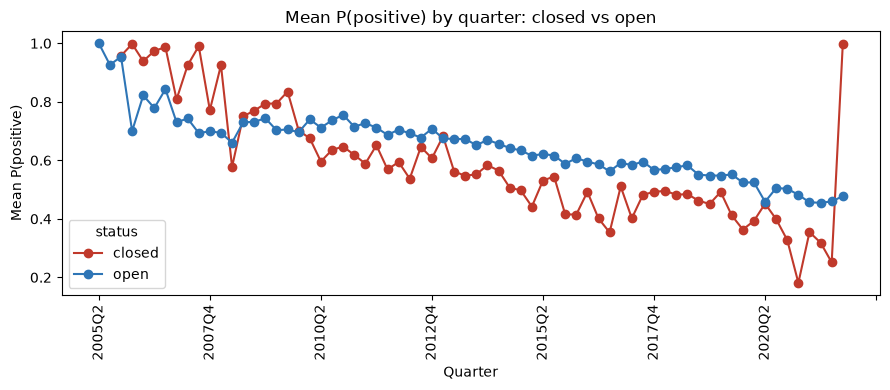

> **Takeaway.** TF-IDF + LinearSVC wins on macro F1 (0.956) and transfers to the cohort at 0.960, so the sentiment features are trustworthy inputs to the survival model.

In [12]:
# Sentiment trajectory: mean P(positive) by quarter for closed vs open locations.
import matplotlib.pyplot as plt

sent = load_artifact(config.REVIEW_SENTIMENT_FILE, base=DATA)
reviews = load_artifact(config.COHORT_REVIEWS_FILE, base=DATA)
loc = load_artifact(config.COHORT_LOCATIONS_FILE)
if sent is not None and reviews is not None and loc is not None:
    df = (sent.merge(reviews[["review_id", "date"]], on="review_id", how="left")
              .merge(loc[["business_id", "is_open"]], on="business_id", how="left"))
    df["date"] = pd.to_datetime(df["date"], errors="coerce")
    df = df.dropna(subset=["date"])
    df["quarter"] = df["date"].dt.to_period("Q").astype(str)
    df["status"] = np.where(df["is_open"] == 0, "closed", "open")
    traj = df.groupby(["quarter", "status"])["p_positive"].mean().unstack()
    ax = traj.plot(figsize=(9, 4), marker="o", color={"closed": "#C0392B", "open": "#2E75B6"})
    ax.set_title("Mean P(positive) by quarter: closed vs open")
    ax.set_xlabel("Quarter"); ax.set_ylabel("Mean P(positive)")
    plt.xticks(rotation=90); plt.tight_layout(); plt.show()
else:
    print("Sentiment trajectory needs review_sentiment, cohort_reviews, and locations.")
takeaway("TF-IDF + LinearSVC wins on macro F1 (0.956) and transfers to the cohort at "
         "0.960, so the sentiment features are trustworthy inputs to the survival model.")

## 5. Complaint themes (LA4): BERTopic

**Question this section answers:** what do customers complain about per cluster, and do
complaints shift over time or differ by outcome?

We model negative reviews (1 to 2 stars) per cluster with BERTopic under a locked UMAP
configuration and track topics over time and by outcome. Topic labels were generated
live by an NVIDIA Llama 3.2 90B model from each topic's top words plus five
representative reviews, and a second call tags each topic as a complaint or a brand
or menu topic. For the survival model we map every topic to one of nine operational
complaint themes by embedding similarity (`artifacts/topic_theme_map.csv`).

In [13]:
for cluster in ("Fast Food", "Non-Fast Food"):
    display(Markdown(f"**Topics: {cluster}**"))
    topics = load_artifact(config.topics_file(cluster))
    if topics is not None:
        display(topics.head(12))
    else:
        show(None)
takeaway("Service failures lead both clusters: poor table service is the largest Fast "
         "Food topic (driven by sit-down brands in that cluster), and slow service and "
         "waits lead Non-Fast Food, followed by food-specific issues such as steak cooking.")

**Topics: Fast Food**

,topic,label,top_words,size,topic_kind
0,0,Disappointing Burger Experience,"burger, fries, burgers, shake, guys, shack, go...",2523,complaint
1,1,Poor table service,"came, minutes, table, server, food, waitress, ...",4645,complaint
2,2,Poor Service and Orders,"fil, chick, chick fil, drive, location, order,...",1502,complaint
3,3,Poor Service at Applebees,"applebee, applebees, food, just, came, like, s...",1316,complaint
4,4,Poor food quality,"subway, sandwich, bread, sandwiches, sub, just...",1304,complaint
5,5,Mixed Feelings About Qdoba,"qdoba, burrito, chipotle, bowl, chips, tacos, ...",1024,brand
6,6,Poor service and food,"wings, hooters, sauce, waitress, boneless, foo...",943,complaint
7,7,Poor service and food,"chili, chilis, food, service, restaurant, just...",988,complaint
8,8,Incorrect food orders,"panda, express, panda express, chicken, orange...",803,complaint
9,9,Poor Service and Food,"denny, dennys, food, coffee, breakfast, waitre...",713,complaint


**Topics: Non-Fast Food**

,topic,label,top_words,size,topic_kind
0,0,Poor service at location,"panera, sandwich, bread, order, soup, location...",1975,complaint
1,1,Slow service and wait,"minutes, table, wait, came, food, asked, said,...",4558,complaint
2,2,Steak cooking issues,"steak, medium, outback, rare, ordered, cooked,...",2141,complaint
3,3,Disappointing Italian food experience,"olive, olive garden, garden, pasta, breadstick...",1047,complaint
4,4,Order pickup issues,"order, pick, called, time, food, minutes, phon...",1383,complaint
5,5,Dry BBQ and service,"bbq, ribs, brisket, pork, dry, pulled pork, pu...",638,complaint
6,6,Disappointing Breakfast Experience,"cracker, barrel, cracker barrel, food, breakfa...",562,complaint
7,7,Poor service and food,"food, good, place, service, like, just, great,...",1475,complaint
8,8,Poor service from waiters,"cheesecake, factory, cheesecake factory, food,...",507,complaint
9,9,PF Changs food quality,"chinese, chang, pf, food, pf chang, chinese fo...",593,brand


> **Takeaway.** Service failures lead both clusters: poor table service is the largest Fast Food topic (driven by sit-down brands in that cluster), and slow service and waits lead Non-Fast Food, followed by food-specific issues such as steak cooking.

In [14]:
# Topics over time and by outcome, if the offline stage wrote them.
slug_map = {"Fast Food": "fast_food", "Non-Fast Food": "non_fast_food"}
for cluster, slug in slug_map.items():
    ot = load_artifact(f"topics_over_time_{slug}.parquet")
    co = load_artifact(f"topics_closed_open_{slug}.parquet")
    if ot is not None:
        display(Markdown(f"**{cluster}: topic volume by quarter (head)**"))
        display(ot.head(10))
    if co is not None:
        display(Markdown(f"**{cluster}: topic counts by outcome (head)**"))
        display(co.head(10))
takeaway("Complaint mix shifts over time and differs between closed and open "
         "locations, which motivates using theme shares as survival features.")

**Fast Food: topic volume by quarter (head)**

,quarter,topic,count
0,2006Q1,5,1
1,2006Q1,7,1
2,2006Q1,15,1
3,2006Q3,4,2
4,2006Q3,7,1
5,2006Q4,11,1
6,2007Q1,0,1
7,2007Q1,11,1
8,2007Q1,15,1
9,2007Q2,5,1


**Fast Food: topic counts by outcome (head)**

,closed_open,topic,count
0,closed,0,133
1,closed,1,402
2,closed,2,12
3,closed,3,100
4,closed,4,216
5,closed,5,81
6,closed,6,209
7,closed,7,74
8,closed,8,13
9,closed,9,99


**Non-Fast Food: topic volume by quarter (head)**

,quarter,topic,count
0,2006Q1,21,1
1,2006Q2,3,1
2,2006Q2,6,1
3,2006Q4,10,1
4,2006Q4,48,1
5,2007Q1,6,1
6,2007Q2,1,1
7,2007Q2,3,1
8,2007Q2,9,3
9,2007Q2,14,1


**Non-Fast Food: topic counts by outcome (head)**

,closed_open,topic,count
0,closed,0,154
1,closed,1,171
2,closed,2,111
3,closed,3,46
4,closed,4,51
5,closed,5,19
6,closed,6,17
7,closed,7,62
8,closed,8,3
9,closed,9,37


> **Takeaway.** Complaint mix shifts over time and differs between closed and open locations, which motivates using theme shares as survival features.

## 6. Survival model: landmark design with chain-grouped validation

**Question this section answers:** does the leakage-safe survival model beat the
stars-only baseline, and where is that evidence strong enough to trust?

We freeze a landmark T = 2018-01-01, build every feature from records dated strictly
before T, and observe closure over the next 24 months, proxying the closure date with
last observed activity. A location is eligible when its first review predates T by at
least 12 months and it shows activity in the six months before T: 1,545 of the 2,054
cohort locations qualify, with 65 closures in the window (59 Fast Food, 6 Non-Fast
Food). The other 509 had already gone quiet before T; scoring them would leak the
outcome, so the app lists them with their observed status instead.

We fit a ridge-penalized Cox proportional hazards model on four nested feature sets
and validate with GroupKFold by chain, so no chain appears in both training and test.
The production design matrix is cleaned before fitting (median imputation with
missingness flags, zero-variance and |r| > 0.95 columns dropped), documented in
`artifacts/feature_decisions.md`.

**Landmark design (schematic).**

```
  first review            T - 6m        T (landmark)                 T + 24 months
  |------------------------|-------------|=============================|----------->
  [ features use ONLY data strictly before T ]   [ outcome window: closure here = event ]
          tenure >= 12m                    activity required
```

Leakage controls: a strict pre-T slice on every source, no feature that looks at or
after T, chain priors computed out of fold, and an activity filter that keeps
already-dormant locations out of the scored set.

In [15]:
# Ablation by scope: Harrell C index under chain-grouped cross validation.
metrics = load_artifact(config.MODEL_METRICS_FILE)
feats = load_artifact(config.features_file(config.LANDMARK_PRIMARY), base=DATA)
if metrics is not None:
    order = ["stars_only", "engagement", "engagement_text", "full", "full_raw_topics"]
    abl = (metrics.pivot_table(index="feature_set", columns="scope", values="harrell_c")
                  .reindex([o for o in order if o in set(metrics["feature_set"])]))
    abl = abl[[c for c in ["pooled", "Fast Food", "Non-Fast Food"] if c in abl.columns]]
    for col in abl.columns:
        abl[f"delta_vs_stars ({col})"] = abl[col] - abl.loc["stars_only", col]
    display(abl.round(3))
if feats is not None and {"event", "cluster"}.issubset(feats.columns):
    ev = feats.groupby("cluster")["event"].agg(events="sum", locations="count")
    display(Markdown("**Closures in the 24-month window by cluster**"))
    display(ev)
takeaway("Fast Food carries the evidence: engagement plus text lifts the C index from "
         "0.640 to 0.677. Pooled, stars alone is a strong baseline (0.656). Non-Fast "
         "Food has only 6 closures, so its C index is not interpretable and we do not "
         "draw conclusions from it.")

scope,pooled,Fast Food,Non-Fast Food,delta_vs_stars (pooled),delta_vs_stars (Fast Food),delta_vs_stars (Non-Fast Food)
feature_set,,,,,,
stars_only,0.656,0.640,0.583,0.000,0.000,0.000
engagement,0.628,0.602,0.375,-0.028,-0.038,-0.208
engagement_text,0.651,0.677,0.379,-0.005,0.037,-0.204
full,0.632,0.657,0.200,-0.023,0.017,-0.383
full_raw_topics,0.593,NaN,NaN,-0.063,NaN,NaN


**Closures in the 24-month window by cluster**

,events,locations
cluster,,
Fast Food,59,1142
Non-Fast Food,6,403


> **Takeaway.** Fast Food carries the evidence: engagement plus text lifts the C index from 0.640 to 0.677. Pooled, stars alone is a strong baseline (0.656). Non-Fast Food has only 6 closures, so its C index is not interpretable and we do not draw conclusions from it.

In [16]:
# Complaint themes versus raw topics in the full pooled model.
metrics = load_artifact(config.MODEL_METRICS_FILE)
if metrics is not None:
    pooled = metrics[metrics["scope"] == "pooled"].set_index("feature_set")["harrell_c"]
    if {"full", "full_raw_topics"}.issubset(pooled.index):
        print(f"Full model, 9 complaint themes : C = {pooled['full']:.3f}")
        print(f"Full model, 68 raw topic shares: C = {pooled['full_raw_topics']:.3f}")
        print(f"Gain from theme collapse       : +{pooled['full'] - pooled['full_raw_topics']:.3f}")
takeaway("Collapsing 68 sparse topic shares into 9 operational themes reduces noise "
         "and raises the pooled C index by 0.039, and the themes are what a manager "
         "can act on.")

Full model, 9 complaint themes : C = 0.632
Full model, 68 raw topic shares: C = 0.593
Gain from theme collapse       : +0.039


> **Takeaway.** Collapsing 68 sparse topic shares into 9 operational themes reduces noise and raises the pooled C index by 0.039, and the themes are what a manager can act on.

**Scope note on the corpus (Tier 1) model.** The proposal planned a second, corpus-wide
Cox model over all ~46K restaurants whose out-of-fold score would be stacked into the
cohort model. Its nested cross validation exceeded our compute budget and was not
completed, so every reported risk score comes from the cohort model above. The stage is
implemented (`pipeline/05b_tier1_survival.py`) and can be run on a larger machine.
Likewise, the 2019 sensitivity landmark features were built but the sensitivity fit is
not reported here.

In [17]:
# Risk scores, tiers, drivers, and survival at 12 and 24 months, joined to city/state.
risk = load_artifact(config.RISK_SCORES_FILE)
loc = load_artifact(config.COHORT_LOCATIONS_FILE)
if risk is not None:
    display(Markdown("**Risk tier by cluster (tiers are cut on the pooled 1,545)**"))
    display(pd.crosstab(risk["cluster"], risk["risk_tier"])
              [[t for t in ["High", "Elevated", "Watch", "Low"] if t in set(risk["risk_tier"])]])
    top = risk.sort_values("risk_score", ascending=False).head(10)
    if loc is not None:
        top = top.merge(loc[["business_id", "city", "state"]], on="business_id", how="left")
    cols = [c for c in ["chain", "city", "state", "cluster", "risk_score",
                        "risk_percentile", "risk_tier", "top_3_drivers",
                        "surv_12m", "surv_24m"] if c in top.columns]
    display(Markdown("**Ten highest-risk locations**"))
    display(top[cols].round(3))
if risk is not None and loc is not None:
    print(f"Cohort coverage: {len(loc):,} locations, {risk['business_id'].nunique():,} "
          f"scored, {len(loc) - risk['business_id'].nunique():,} inactive before the landmark.")
takeaway("All 155 High-tier locations are Fast Food, consistent with the EDA finding "
         "that Fast Food closes more often. Among them the recurring drivers are the "
         "chain's out-of-fold closure prior (155), the share of negative reviews (134), "
         "and mean review sentiment (103).")

**Risk tier by cluster (tiers are cut on the pooled 1,545)**

risk_tier,High,Elevated,Watch,Low
cluster,,,,
Fast Food,155,228,323,436
Non-Fast Food,0,4,63,336


**Ten highest-risk locations**

,chain,city,state,cluster,risk_score,risk_percentile,risk_tier,top_3_drivers,surv_12m,surv_24m
0,Subway,Town And Country,MO,Fast Food,2.165,100.000,High,"chain_prior, theme_management_response, share_...",0.963,0.911
1,Jimmy John's,Boise,ID,Fast Food,2.099,99.935,High,"theme_management_response, chain_prior, share_...",0.964,0.914
2,Subway,Indianapolis,IN,Fast Food,1.723,99.871,High,"chain_prior, share_negative, sentiment_mean",0.970,0.929
3,Subway,St Petersburg,FL,Fast Food,1.706,99.806,High,"chain_prior, share_negative, sentiment_mean",0.970,0.929
4,Subway,Lutz,FL,Fast Food,1.699,99.741,High,"chain_prior, share_negative, sentiment_mean",0.970,0.930
5,Jimmy John's,St. Petersburg,FL,Fast Food,1.662,99.676,High,"chain_prior, share_negative, tip_coverage",0.971,0.931
6,Subway,Tampa,FL,Fast Food,1.639,99.612,High,"chain_prior, share_negative, sentiment_mean",0.971,0.932
7,Subway,Sparks,NV,Fast Food,1.634,99.547,High,"chain_prior, theme_management_response, share_...",0.972,0.932
8,Subway,Edwardsville,IL,Fast Food,1.622,99.482,High,"chain_prior, sentiment_slope, tip_coverage",0.972,0.933
9,Red Robin Gourmet Burgers and Brews,Edmonton,AB,Fast Food,1.609,99.417,High,"theme_order_accuracy, chain_prior, sentiment_mean",0.972,0.933


Cohort coverage: 2,054 locations, 1,545 scored, 509 inactive before the landmark.


> **Takeaway.** All 155 High-tier locations are Fast Food, consistent with the EDA finding that Fast Food closes more often. Among them the recurring drivers are the chain's out-of-fold closure prior (155), the share of negative reviews (134), and mean review sentiment (103).

In [18]:
# Survival curves feed the Location Deep Dive page.
curves = load_artifact(config.SURVIVAL_CURVES_FILE)
if curves is not None:
    print(f"Survival curves: {curves['business_id'].nunique():,} locations, "
          f"{len(curves):,} rows (t_days, survival).")
    display(curves.head(6))

Survival curves: 1,545 locations, 38,625 rows (t_days, survival).


,business_id,t_days,survival
0,il_Ro8jwPlHresjw9EGmBg,0,0.999291
1,il_Ro8jwPlHresjw9EGmBg,30,0.998742
2,il_Ro8jwPlHresjw9EGmBg,60,0.996675
3,il_Ro8jwPlHresjw9EGmBg,91,0.994616
4,il_Ro8jwPlHresjw9EGmBg,121,0.992709
5,il_Ro8jwPlHresjw9EGmBg,152,0.992169


## 7. LLM layer (LA5): gateway, aspect agents, RAG, and the Risk Committee

**Question this section answers:** how do we call models reliably, and can a committee
of agents produce grounded, auditable evidence without inventing numbers?

Every model call goes through an LLM gateway that routes task roles to ordered
provider fallback chains, verifies model ids, checks provider health, retries with
backoff, caches to disk, and records a usage ledger. On top of the gateway, a Risk
Committee of three agents writes each Location Risk Brief: a Quant Analyst (templates
with placeholders only, Python fills the numbers), a Voice of Customer (grounded
quotes with issue labels), and a different-family Risk Auditor that checks every
claim. Python orchestrates them, grounds quotes, renders numbers, and derives the
confidence grade. All reported LLM results were produced in strict live mode: a
mock answer raises an error instead of passing as a model result, and cached mock
answers are never reused.

**Gateway architecture.**

```mermaid
flowchart LR
  C[Caller: topics / aspects / rag / agents] -->|role + messages| G[LLM Gateway]
  G --> R[Role routing: config/gateway.yaml]
  R --> H{Provider healthy?}
  H -->|yes| P1[NVIDIA Llama 3.2 90B]
  H -->|yes| P2[NVIDIA Llama 3.2 11B]
  P1 --> Q[retry + backoff, JSON repair, cache, ledger]
  P2 --> Q
  R -.->|offline tests only| M[mock]
  Q --> S{Strict live mode}
  S -->|mock answer| E[raise error, never silently mock]
  Q --> O[GatewayResult: text, provider, model, cache_hit, fallback_used]
```

**Risk Committee.**

```mermaid
flowchart TD
  F[Python fact sheet] --> A1[Agent 1 Quant Analyst]
  S[RAG snippets MMR, negative weighted] --> A2[Agent 2 Voice of Customer]
  A1 -->|rendered drivers| CL[Python builds claims]
  A2 -->|grounded issues| CL
  CL --> A3[Agent 3 Risk Auditor, different family]
  A3 -->|verdicts + grade| AS[Python assembles brief]
  AS --> B[Location Risk Brief: drivers, evidence, confidence, actions]
```

In [19]:
aspect_eval = load_artifact(config.ASPECT_EVAL_FILE)
if aspect_eval is not None:
    display(Markdown("**Aspect agents (food, service, ambience): predicted vs actual stars, "
                     "150 reviews stratified by star rating, 5 per chain**"))
    display(aspect_eval.round(4))
else:
    print("Run pipeline/06_aspects_rag.py --phase aspects for the aspect evaluation.")

rag_eval = load_artifact(config.RAG_EVAL_FILE)
if rag_eval is not None:
    display(Markdown("**RAG evaluation: groundedness and retrieval**"))
    display(rag_eval.round(4))
    print("Groundedness is judged per sentence by a separate 11B model with a strict "
          "rubric; unsupported sentences are hidden in the app, not shown as fact.")

**Aspect agents (food, service, ambience): predicted vs actual stars, 150 reviews stratified by star rating, 5 per chain**

,accuracy,macro_f1,mae,pearson_r,n,contrast_p,contrast_effect
0,0.6533,0.6328,0.4578,0.9073,150,NaN,NaN


**RAG evaluation: groundedness and retrieval**

,n_locations,n_answers,mean_groundedness,retrieval_nonempty_rate
0,10,60,0.3625,0.8833


Groundedness is judged per sentence by a separate 11B model with a strict rubric; unsupported sentences are hidden in the app, not shown as fact.


In [20]:
# A cached RAG answer with citations and the judge-filtered visible answer.
cache = load_artifact(config.RAG_CACHE_FILE)
if cache is not None and len(cache):
    ex = cache.iloc[0]
    display(Markdown(
        f"**Example question:** {ex['question']}\n\n"
        f"**Answer (with citations):** {ex['answer']}\n\n"
        f"**Visible answer (judge-supported only):** {ex['visible_answer']}\n\n"
        f"**Groundedness rate:** {ex['groundedness_rate']:.2f}"
    ))
else:
    print("Run pipeline/06_aspects_rag.py --phase rag to build rag_cache.parquet.")
takeaway("Two different-family models plus quote grounding give evidence an operator "
         "can trust: every claim is cited and unsupported sentences are hidden.")

**Example question:** Why is this location at risk?

**Answer (with citations):** This location is at risk due to its poor customer service and management issues. The employees are often rude and argumentative [xomVeb2Im2e4WGPfYrmyfQ#0], and the manager has been known to be uncooperative and dismissive of customer complaints [ECaSFx0TxEZ68Y_gPXz6wA#0, _PedOViFip9v9awvd1hjCg#2]. Additionally, the store has been known to have issues with food preparation and delivery, such as not including all the ordered toppings [Db9KO_ftXYc3TFeyAiEntw#0] and not having certain items available [eKmHZAJrIp5iHz99blIdsQ#0]. The location's poor service and management have led to a loss of customer trust and loyalty, with many reviewers stating that they will not return [tip_13787#0, _PedOViFip9v9awvd1hjCg#1, ECaSFx0TxEZ68Y_gPXz6wA#0].

**Visible answer (judge-supported only):** The employees are often rude and argumentative [xomVeb2Im2e4WGPfYrmyfQ#0], and the manager has been known to be uncooperative and dismissive of customer complaints [ECaSFx0TxEZ68Y_gPXz6wA#0, _PedOViFip9v9awvd1hjCg#2]. Additionally, the store has been known to have issues with food preparation and delivery, such as not including all the ordered toppings [Db9KO_ftXYc3TFeyAiEntw#0] and not having certain items available [eKmHZAJrIp5iHz99blIdsQ#0].

**Groundedness rate:** 0.50

> **Takeaway.** Two different-family models plus quote grounding give evidence an operator can trust: every claim is cited and unsupported sentences are hidden.

In [21]:
# Risk Committee evaluation: independent numeric-fidelity re-scan (every number in a
# rendered driver must trace to the Python fact sheet), groundedness, auditor
# rejection rate, and latency/cost per brief from the gateway ledger.
agent_eval = load_artifact(config.AGENT_EVAL_FILE)
if agent_eval is not None:
    cols = [c for c in ["n_briefs", "n_skipped_timeouts", "numeric_fidelity_rate",
                        "mean_groundedness", "auditor_rejection_rate", "mean_latency_s",
                        "total_est_cost_usd"]
            if c in agent_eval.columns]
    display(agent_eval[cols].round(4))
    from lrr import agents as _agents
    display(Markdown(f"**Confidence formula.** {_agents.CONFIDENCE_FORMULA}"))
else:
    print("Run pipeline/08_eval_agents.py for the committee evaluation.")
takeaway("On 10 live briefs, numeric fidelity is 1.0 (every number traces to the "
         "Python fact sheet), and the auditor removes 40% of claims as unsupported, "
         "which is the committee doing its job rather than rubber-stamping.")

,n_briefs,n_skipped_timeouts,numeric_fidelity_rate,mean_groundedness,auditor_rejection_rate,mean_latency_s,total_est_cost_usd
0,10,0,1.0,0.4436,0.4,26.2469,0.0


**Confidence formula.** confidence = groundedness_rate * min(1, grounded_evidence_count / 5) * grade_weight[grade], where grade_weight = {'A': 1.0, 'B': 0.7, 'C': 0.4}. The result is clamped to [0, 1] and labeled High >= 0.66, Medium >= 0.33, else Low.

> **Takeaway.** On 10 live briefs, numeric fidelity is 1.0 (every number traces to the Python fact sheet), and the auditor removes 40% of claims as unsupported, which is the committee doing its job rather than rubber-stamping.

In [22]:
# One full Location Risk Brief for a High-risk location, as the app renders it.
briefs = load_artifact(config.BRIEFS_FILE)
if briefs is not None and len(briefs):
    high = briefs[briefs["tier"] == "High"]
    row = (high.iloc[0] if len(high) else briefs.iloc[0])
    _loc = load_artifact(config.COHORT_LOCATIONS_FILE)
    _name = row["business_id"]
    if _loc is not None:
        _m = _loc[_loc["business_id"] == row["business_id"]]
        if len(_m):
            _r = _m.iloc[0]
            _name = f"{_r['chain']}, {_r['city']}, {_r['state']} ({_r['cluster']})"
    md_brief = (
        f"### Location Risk Brief: {_name}\n\n"
        f"**Tier:** {row['tier']}  |  **Confidence:** {row.get('confidence_label','')} "
        f"({row.get('confidence', float('nan')):.2f})  |  "
        f"**Groundedness:** {row.get('groundedness', float('nan')):.2f}\n\n"
        f"**Why we flagged it (drivers):**\n\n"
        f"{str(row.get('drivers','')).replace(row['business_id'], _name)}\n\n"
        f"**Evidence (grounded quotes with citations):**\n\n{row.get('evidence','')}\n\n"
        f"**Recommended actions:**\n\n{row.get('actions','')}"
    )
    display(Markdown(md_brief))
else:
    print("Run pipeline/08_eval_agents.py to precompute briefs for High/Elevated "
          "locations into artifacts/briefs.parquet.")
takeaway("The committee turns scattered reviews into one auditable brief: a tier, "
         "number-faithful drivers, cited evidence, a confidence grade, and concrete "
         "actions from the operations playbook.")

### Location Risk Brief: Subway, Town And Country, MO (Fast Food)

**Tier:** High  |  **Confidence:** Low (0.00)  |  **Groundedness:** 0.33

**Why we flagged it (drivers):**

The business Subway, Town And Country, MO (Fast Food) is part of the Subway chain, which has a high risk profile, contributing to its High risk tier and 100.00 risk percentile.

**Evidence (grounded quotes with citations):**



**Recommended actions:**



> **Takeaway.** The committee turns scattered reviews into one auditable brief: a tier, number-faithful drivers, cited evidence, a confidence grade, and concrete actions from the operations playbook.

## 8. App walkthrough

**Question this section answers:** how does an operator actually use this?

The Streamlit app has seven pages:

- **Portfolio Radar:** all 2,054 cohort locations on a tier-colored map with metro
  labels, a sortable watchlist (chain, city, state, cluster, tier, drivers), and
  global filters for cluster, chain, state, and tier.
- **Location Deep Dive:** one location's risk score, percentile, 12 and 24-month
  survival, survival curve, and drivers.
- **Risk Committee:** the three-agent brief, cached instantly or convened live with
  per-agent progress, model, and latency.
- **Complaint Themes:** BERTopic topics per cluster, over time and by outcome.
- **Ask the Reviews:** grounded Q&A with numbered citations that expand to the source
  review.
- **Model Lab:** survival ablation, sentiment benchmark, aspect and agent evaluations.
- **Methodology and Limitations.**

It reads only small precomputed artifacts, so it works with no API key in Cached mode;
Live mode routes through the same gateway with a per-session call cap.

In [23]:
from IPython.display import Image

# Screenshots live in docs/screenshots/. We show them when present so Run All stays
# clean on a fresh checkout.
shots = [
    ("Portfolio risk view", ROOT / "docs" / "screenshots" / "portfolio.png"),
    ("Location detail with drivers and survival curve", ROOT / "docs" / "screenshots" / "location.png"),
    ("Evidence assistant with citations", ROOT / "docs" / "screenshots" / "assistant.png"),
]
shown = False
for caption, path in shots:
    if path.exists():
        display(Markdown(f"**{caption}**"))
        display(Image(filename=str(path)))
        shown = True
if not shown:
    display(Markdown(
        "_Screenshots are in `docs/screenshots/` in the repo; the live app link is at "
        "the top of this notebook._"))
takeaway("The app turns the models into a one-screen triage tool backed by readable "
         "evidence, which is the whole point for a busy regional manager.")

_Screenshots are in `docs/screenshots/` in the repo; the live app link is at the top of this notebook._

> **Takeaway.** The app turns the models into a one-screen triage tool backed by readable evidence, which is the whole point for a busy regional manager.

## 9. Limitations, threats to validity, and ethics

**Question this section answers:** where could this be wrong, and how should it be used
responsibly?

We state the known limitations plainly, carried from the product definition:

- **No chain id.** Chains are grouped by normalized name, which is imperfect.
- **Fast Food label noise.** Sit-down brands such as Chili's, Applebee's, and Denny's
  appear in the Fast Food cluster; we keep the EDA's cluster definition unchanged.
- **Few Non-Fast Food closures.** Only 6 of 403 eligible Non-Fast Food locations close
  in the window, so Non-Fast Food survival metrics are not interpretable and its
  locations rarely reach the High tier.
- **509 inactive locations are not scored.** They had no activity in the six months
  before the landmark; scoring them would leak the outcome.
- **Corpus model not fit.** The planned Tier 1 corpus model and the 2019 sensitivity
  fit were not completed within our compute budget.
- **LLM evaluation sample sizes.** Aspect agents are evaluated on 150 reviews, the RAG
  cache on 60 answers (10 locations), and the committee on 10 briefs.
- **`is_open` is a status, not a closure date.** We proxy the closure date with last
  observed activity, so late censoring is approximate.
- **Right censoring.** Locations still open at the window's end have unknown eventual
  outcomes.
- **Survivorship in text.** Reviews stop when a location stops, biasing late-period
  language.

Additional threats to validity: the COVID shock after early 2020 distorts activity and
closure patterns, so we read the 2018 landmark as primary and treat 2019 as a
sensitivity check. Geographic coverage in the Yelp data is uneven: it covers about 14
metro areas, so results describe those markets, not chains nationally.

Ethics: the tool supports human triage, not automated decisions about people. It
should never be used to justify adverse employment action; it points managers toward
locations that merit a closer look, with the evidence attached.

In [24]:
# Echo the limitations from steering so the notebook and product stay in sync.
limitations = [
    "No chain_id; chains grouped by normalized name.",
    "Fast Food label noise (Chili's, Applebee's, Denny's in the Fast Food cluster).",
    "Only 6 Non-Fast Food closures in the window; its C index is not interpretable.",
    "509 locations inactive before the landmark are reported, not scored.",
    "Tier 1 corpus model and 2019 sensitivity fit not completed.",
    "is_open is a status, not a closure date.",
    "Closure date proxied by last activity.",
    "Right censoring at the end of the observation window.",
    "Survivorship in text for closed locations.",
]
for i, item in enumerate(limitations, 1):
    print(f"{i}. {item}")
takeaway("The model is a decision aid under real data limits; naming those limits is "
         "what makes the risk scores usable rather than misleading.")

1. No chain_id; chains grouped by normalized name.
2. Fast Food label noise (Chili's, Applebee's, Denny's in the Fast Food cluster).
3. Only 6 Non-Fast Food closures in the window; its C index is not interpretable.
4. 509 locations inactive before the landmark are reported, not scored.
5. Tier 1 corpus model and 2019 sensitivity fit not completed.
6. is_open is a status, not a closure date.
7. Closure date proxied by last activity.
8. Right censoring at the end of the observation window.
9. Survivorship in text for closed locations.


> **Takeaway.** The model is a decision aid under real data limits; naming those limits is what makes the risk scores usable rather than misleading.

## 10. Conclusions and recommendations for operators

**Question this section answers:** what should an operator do with this?

The star rating barely separates open from closed restaurants (0.026 stars). In Fast
Food, where closures are frequent enough to model, engagement and review language
lift the survival model's ranking beyond stars, and operational complaint themes beat
raw topics. Non-Fast Food closes far less often, which is itself the cluster contrast
the EDA predicted. For operators we recommend:

1. **Triage by tier weekly.** Review High and Elevated locations first; the tiers are
   calibrated percentiles, not raw scores.
2. **Read the evidence, not just the score.** Use the top drivers and the cited RAG
   answers to decide whether a flag reflects a fixable operational issue.
3. **Act on engagement decay early.** Falling review and check-in velocity precedes
   closure by a wide margin, which is where intervention is cheapest.
4. **Treat Fast Food and Non-Fast Food differently.** Complaint mixes and closure
   dynamics differ, so the playbook should too.

**Takeaway:** the system converts scattered customer text into a ranked, explained
watchlist that lets operators intervene while there is still time.

## 11. Generative AI and collaboration disclosure

**Question this section answers:** how did we use generative AI, and who did what?

We used generative AI tools as assistants under human direction and review:

- **Kiro** (agentic IDE) scaffolded the `src/lrr` package, the pipeline stages, and the
  test suite, and drafted this notebook. We reviewed and edited all generated code.
- **ChatGPT, Gemini, and Claude** were used for targeted help with prompt design for
  the aspect agents and the RAG judge, for debugging, and for wording. No model made
  modeling or data decisions on its own.

All numbers in this notebook are computed by our Python code from the artifacts, not
written by a language model. The LLM layer itself returns only quotes and labels; every
score is computed in `src/lrr`.

**Team contributions.**

- **Andy Lin:** EDA, cohort reproduction, data quality.
- **Hunain Akbar:** survival modeling, features, evaluation.
- **Ishani Patel:** topic modeling and complaint-theme interpretation.
- **Jake Ida:** sentiment modeling and the benchmark.
- **Yukti Gandhi:** LLM aspect agents, RAG assistant, and the app.

All members contributed to the write-up and reviewed the final notebook.

**Takeaway:** generative AI accelerated the engineering and writing, while the analysis,
decisions, and every reported number remain ours.

## 12. Export to HTML

**Question this section answers:** how do we produce the submission artifact?

The cell below exports this notebook to a self-contained HTML file with nbconvert.
Running it after Run All captures every output in the exported file.

In [25]:
# Export this notebook to HTML. Run after Run All so outputs are embedded.
import subprocess

NOTEBOOK = "Location_Risk_Radar_Final.ipynb"
try:
    out = subprocess.run(
        ["jupyter", "nbconvert", "--to", "html", "--embed-images", NOTEBOOK],
        capture_output=True, text=True, cwd=str(Path.cwd()),
    )
    print(out.stdout or "nbconvert finished.")
    if out.returncode != 0:
        print(out.stderr)
        print("If nbconvert is missing, run: pip install nbconvert")
except FileNotFoundError:
    print("jupyter/nbconvert not found. Install with: pip install nbconvert")
takeaway("One command produces the self-contained HTML deliverable with all outputs "
         "visible, matching the Run All state.")

nbconvert finished.


> **Takeaway.** One command produces the self-contained HTML deliverable with all outputs visible, matching the Run All state.